In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END
from IPython.display import Image
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class BLOGState(TypedDict):
    topic: str
    outline: str
    content: str

In [4]:
def Create_Outline(state: BLOGState) -> BLOGState:
    topic = state['topic']
    prompt = f"Create a detailed outline for a blog post about: {topic}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [5]:
def Write_Blog(state: BLOGState) -> BLOGState:
    outline = state['outline']
    prompt = f"Write a blog post based on the following outline: {outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [6]:
graph = StateGraph(BLOGState)

#add node
graph.add_node("Create-Outline", Create_Outline)
graph.add_node("Write-Blog", Write_Blog)

#add edges
graph.add_edge(START, "Create-Outline")
graph.add_edge("Create-Outline", "Write-Blog")
graph.add_edge("Write-Blog", END)

#compile workflow
workflow = graph.compile()

{'topic': 'The Future of AI in Healthcare', 'outline': 'Here\'s a detailed outline for a blog post about "The Future of AI in Healthcare," designed to be comprehensive, engaging, and informative.\n\n---\n\n## Blog Post Outline: The Future of AI in Healthcare: Revolutionizing Wellness, Diagnostics, and Treatment\n\n**Target Audience:** Healthcare professionals, tech enthusiasts, patients, policymakers, general public interested in future trends.\n**Tone:** Optimistic yet realistic, informative, forward-looking, balanced.\n**Keywords:** AI in healthcare, future of medicine, artificial intelligence, medical technology, digital health, personalized medicine, diagnostics, drug discovery, preventative care, healthcare innovation.\n\n---\n\n### I. Catchy Title Options:\n*   The AI Doctor Will See You Now: How Artificial Intelligence is Reshaping Healthcare\'s Future\n*   Beyond the Hype: Unlocking the True Potential of AI in Modern Medicine\n*   From Diagnosis to Discovery: The Transformative

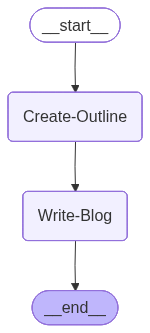

In [7]:
#execute workflow
initial_state = BLOGState(topic="The Future of AI in Healthcare")

final_blog = workflow.invoke(initial_state)
print(final_blog)

#generate visualization
Image(workflow.get_graph().draw_mermaid_png())


In [8]:
print(final_blog['outline'])

Here's a detailed outline for a blog post about "The Future of AI in Healthcare," designed to be comprehensive, engaging, and informative.

---

## Blog Post Outline: The Future of AI in Healthcare: Revolutionizing Wellness, Diagnostics, and Treatment

**Target Audience:** Healthcare professionals, tech enthusiasts, patients, policymakers, general public interested in future trends.
**Tone:** Optimistic yet realistic, informative, forward-looking, balanced.
**Keywords:** AI in healthcare, future of medicine, artificial intelligence, medical technology, digital health, personalized medicine, diagnostics, drug discovery, preventative care, healthcare innovation.

---

### I. Catchy Title Options:
*   The AI Doctor Will See You Now: How Artificial Intelligence is Reshaping Healthcare's Future
*   Beyond the Hype: Unlocking the True Potential of AI in Modern Medicine
*   From Diagnosis to Discovery: The Transformative Power of AI in Healthcare
*   The Future is Smart: Navigating AI's Revol